# Phase 3 -- Illustrative MWPM threshold sweep (d=3, d=5)

This notebook runs a **small illustrative** Monte-Carlo sweep of the
MWPM decoder against the rotated surface code under uniform depolarizing
noise. We sweep `p_phys` over six points in `[0.005, 0.02]` for distances
`d in {3, 5}` with `rounds = d`.

It is **not** a publication-quality threshold estimate. We use a
deliberately small shot count (10 000 shots per point) to keep total
runtime under ~60 s. Distance 7 is dropped here because at the same
shot count it would more than triple wall-clock and the resulting curve
would still be statistics-limited; the proper sweep up to d=7 will live
in the capstone harness with shots in the hundreds of thousands.

The y-axis is **logical error rate per round** (Fowler et al. 2012,
arXiv:1208.0928): `1 - (1 - p_L)**(1/rounds)`.


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from qec_project.codes.surface_code import rotated_surface_code_circuit
from qec_project.decoders.mwpm import MwpmDecoder

RNG_SEED = 20260515
DISTANCES = (3, 5)
P_PHYS_GRID = np.linspace(0.005, 0.02, 6)
SHOTS_PER_POINT = 10_000

print(f'distances = {DISTANCES}')
print(f'p_phys grid = {P_PHYS_GRID}')
print(f'shots per point = {SHOTS_PER_POINT}')


distances = (3, 5)
p_phys grid = [0.005 0.008 0.011 0.014 0.017 0.02 ]
shots per point = 10000


In [2]:
def logical_error_rate(distance: int, rounds: int, p_phys: float,
                       shots: int, seed: int) -> float:
    circuit = rotated_surface_code_circuit(distance, rounds, p_phys)
    decoder = MwpmDecoder.from_circuit(circuit)
    sampler = circuit.compile_detector_sampler(seed=seed)
    dets, obs = sampler.sample(shots=shots, separate_observables=True)
    pred = decoder.decode_batch(dets)
    errors = (pred ^ obs.astype(np.uint8)).any(axis=1).sum()
    return float(errors) / shots


def per_round(p_logical: float, rounds: int) -> float:
    if p_logical <= 0.0:
        return 0.0
    return 1.0 - (1.0 - p_logical) ** (1.0 / rounds)


In [3]:
results: list[dict] = []
rng = np.random.default_rng(RNG_SEED)
for d in DISTANCES:
    rounds = d
    for p in P_PHYS_GRID:
        seed = int(rng.integers(0, 2**31 - 1))
        p_l = logical_error_rate(d, rounds, float(p), SHOTS_PER_POINT, seed)
        results.append({
            'd': d,
            'rounds': rounds,
            'p_phys': float(p),
            'shots': SHOTS_PER_POINT,
            'p_logical': p_l,
            'p_logical_per_round': per_round(p_l, rounds),
            'seed': seed,
        })
        print(f'd={d} rounds={rounds} p_phys={p:.4f}  p_L={p_l:.4f}')


d=3 rounds=3 p_phys=0.0050  p_L=0.0175
d=3 rounds=3 p_phys=0.0080  p_L=0.0383
d=3 rounds=3 p_phys=0.0110  p_L=0.0720
d=3 rounds=3 p_phys=0.0140  p_L=0.1030
d=3 rounds=3 p_phys=0.0170  p_L=0.1372
d=3 rounds=3 p_phys=0.0200  p_L=0.1721
d=5 rounds=5 p_phys=0.0050  p_L=0.0159
d=5 rounds=5 p_phys=0.0080  p_L=0.0500


d=5 rounds=5 p_phys=0.0110  p_L=0.1024


d=5 rounds=5 p_phys=0.0140  p_L=0.1708


d=5 rounds=5 p_phys=0.0170  p_L=0.2446


d=5 rounds=5 p_phys=0.0200  p_L=0.3053


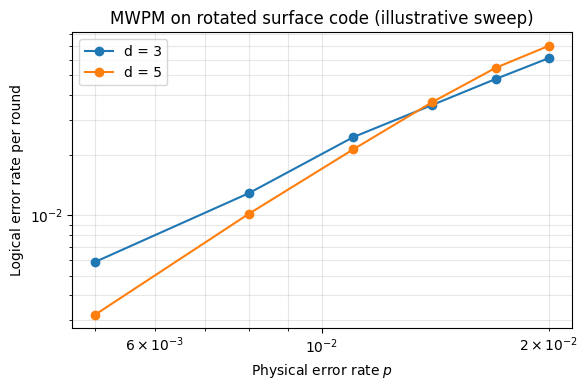

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
for d in DISTANCES:
    rows = [r for r in results if r['d'] == d]
    xs = [r['p_phys'] for r in rows]
    ys = [r['p_logical_per_round'] for r in rows]
    ax.plot(xs, ys, marker='o', label=f'd = {d}')
ax.set_xlabel('Physical error rate $p$')
ax.set_ylabel('Logical error rate per round')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('MWPM on rotated surface code (illustrative sweep)')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


In [5]:
header = f"{'d':>3} {'p_phys':>8} {'p_logical':>12} {'shots':>8}"
print(header)
for r in results:
    print(f"{r['d']:>3} {r['p_phys']:>8.4f} {r['p_logical']:>12.5f} {r['shots']:>8d}")


  d   p_phys    p_logical    shots
  3   0.0050      0.01750    10000
  3   0.0080      0.03830    10000
  3   0.0110      0.07200    10000
  3   0.0140      0.10300    10000
  3   0.0170      0.13720    10000
  3   0.0200      0.17210    10000
  5   0.0050      0.01590    10000
  5   0.0080      0.05000    10000
  5   0.0110      0.10240    10000
  5   0.0140      0.17080    10000
  5   0.0170      0.24460    10000
  5   0.0200      0.30530    10000


**Caveats.** Curves may not cross convincingly at 10 000 shots per point
-- the Monte-Carlo error bar at p_L ~ 0.005 is roughly
sqrt(0.005 / 10 000) ~ 7e-4, comparable to the difference between
d=3 and d=5 near threshold. The proper crossing plot belongs in the
capstone with sinter-driven sweeps and >=1e5 shots per point.
